# SparkCity Weather Feature — Day 4

**Owner:** Matthew Baise  
**Focus:** Anomaly detection, alerting, predictive modeling, and pipeline optimization

## Purpose

This notebook demonstrates the reusable SparkCity weather package on the complete weather dataset. It creates data-driven alerts, multivariate anomaly scores, next-hour temperature forecasts, validation metrics, and performance benchmarks.

In [1]:
from pathlib import Path
from time import perf_counter

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from sparkcityx import (
    WeatherAlertThresholds,
    add_multivariate_anomaly_scores,
    add_threshold_alerts,
    add_weather_rolling_features,
    aggregate_hourly_weather,
    load_dataset,
    score_isolation_forest,
    train_temperature_forecaster,
    validate_dataframe,
)

In [2]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SparkCity-Weather-Day4")
    .config("spark.ui.enabled", "false")
    .config("spark.sql.adaptive.enabled", "true")
    .config(
        "spark.sql.adaptive.coalescePartitions.enabled",
        "true",
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Spark master: {spark.sparkContext.master}")
print(
    "Adaptive execution:",
    spark.conf.get("spark.sql.adaptive.enabled"),
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/15 15:45:31 WARN Utils: Your hostname, Zipcoders-MacBook-8.local, resolves to a loopback address: 127.0.0.1; using 192.168.88.14 instead (on interface en0)
26/09/15 15:45:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/15 15:45:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0
Spark master: local[*]
Adaptive execution: true


In [3]:
weather_path = Path("../data/raw/weather_data.parquet")

if not weather_path.exists():
    weather_path = Path("data/raw/weather_data.parquet")

weather_df = load_dataset(spark, weather_path).cache()
weather_count = weather_df.count()
weather_report = validate_dataframe(weather_df, "weather")

print(f"Source: {weather_path.resolve()}")
print(f"Records: {weather_count:,}")
print(f"Partitions: {weather_df.rdd.getNumPartitions()}")
print(f"Valid source: {weather_report['valid']}")

26/09/15 15:45:37 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Source: /Users/matthew/Projects/SparkCity_Capstone/data/raw/weather_data.parquet
Records: 36,000
Partitions: 1
Valid source: True


## 1. Data-Driven Alert Thresholds

The dataset does not document measurement units. Therefore, these thresholds represent unusual values within this dataset—not official emergency weather standards.

In [4]:
temperature_low, temperature_high = weather_df.approxQuantile(
    "temperature",
    [0.01, 0.99],
    0.01,
)

wind_high = weather_df.approxQuantile(
    "wind_speed",
    [0.95],
    0.01,
)[0]

positive_precipitation_df = weather_df.filter(
    F.col("precipitation") > 0
)

precipitation_high = positive_precipitation_df.approxQuantile(
    "precipitation",
    [0.95],
    0.01,
)[0]

pressure_low, pressure_high = weather_df.approxQuantile(
    "pressure",
    [0.01, 0.99],
    0.01,
)

alert_thresholds = WeatherAlertThresholds(
    minimum_temperature=temperature_low,
    maximum_temperature=temperature_high,
    maximum_wind_speed=wind_high,
    maximum_precipitation=precipitation_high,
    minimum_pressure=pressure_low,
    maximum_pressure=pressure_high,
)

print(alert_thresholds)

WeatherAlertThresholds(minimum_temperature=33.01, maximum_temperature=70.98, maximum_wind_speed=21.53, maximum_precipitation=0.392, minimum_pressure=1002.0, maximum_pressure=1022.0)


## 2. Threshold and Multivariate Anomaly Detection

Threshold alerts explain which measurements crossed a configured boundary. Multivariate scoring identifies unusual combinations of otherwise related measurements.

In [5]:
alerted_weather_df = add_threshold_alerts(
    weather_df,
    alert_thresholds,
)

scored_weather_df = add_multivariate_anomaly_scores(
    alerted_weather_df,
    score_threshold=4.0,
).cache()

scored_count = scored_weather_df.count()

print(f"Scored records: {scored_count:,}")

Scored records: 36,000


In [6]:
(
    scored_weather_df
    .groupBy("alert_severity")
    .count()
    .withColumn(
        "percentage",
        F.round(F.col("count") / scored_count * 100, 2),
    )
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

+--------------+-----+----------+
|alert_severity|count|percentage|
+--------------+-----+----------+
|NORMAL        |32539|90.39     |
|WARNING       |3367 |9.35      |
|CRITICAL      |94   |0.26      |
+--------------+-----+----------+



In [7]:
scored_weather_df.select(
    "multivariate_anomaly_score"
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "50%",
    "95%",
    "max",
).show(truncate=False)

multivariate_anomaly_count = scored_weather_df.filter(
    F.col("is_multivariate_anomaly")
).count()

print(
    "Multivariate anomalies:",
    f"{multivariate_anomaly_count:,}",
)
print(
    "Multivariate anomaly rate:",
    f"{multivariate_anomaly_count / scored_count * 100:.2f}%",
)

+-------+--------------------------+
|summary|multivariate_anomaly_score|
+-------+--------------------------+
|count  |36000                     |
|mean   |2.161779344592486         |
|stddev |0.5714720011322099        |
|min    |0.22651245708417514       |
|50%    |2.166737773590996         |
|95%    |3.065838536808601         |
|max    |5.604201906726485         |
+-------+--------------------------+

Multivariate anomalies: 131
Multivariate anomaly rate: 0.36%


In [8]:
weather_investigation_df = (
    scored_weather_df
    .withColumn(
        "investigation_priority",
        F.when(
            F.col("alert_severity") == "CRITICAL",
            F.lit("CRITICAL"),
        )
        .when(
            F.col("is_multivariate_anomaly")
            & (F.col("alert_severity") == "WARNING"),
            F.lit("HIGH"),
        )
        .when(
            F.col("is_multivariate_anomaly"),
            F.lit("MODEL_REVIEW"),
        )
        .when(
            F.col("alert_severity") == "WARNING",
            F.lit("THRESHOLD_REVIEW"),
        )
        .otherwise(F.lit("NORMAL")),
    )
    .withColumn(
        "investigation_id",
        F.concat_ws(
            "-",
            F.col("station_id"),
            F.date_format("timestamp", "yyyyMMddHHmmss"),
        ),
    )
)

In [9]:
(
    weather_investigation_df
    .filter(F.col("investigation_priority") != "NORMAL")
    .select(
        "investigation_id",
        "station_id",
        "timestamp",
        "investigation_priority",
        "alert_reasons",
        "multivariate_anomaly_score",
        "temperature",
        "humidity",
        "wind_speed",
        "precipitation",
        "pressure",
    )
    .orderBy(
        F.desc("multivariate_anomaly_score"),
        "timestamp",
    )
    .show(25, truncate=False)
)

+-----------------------+----------+-------------------+----------------------+----------------------------+--------------------------+-----------+--------+----------+-------------+--------+
|investigation_id       |station_id|timestamp          |investigation_priority|alert_reasons               |multivariate_anomaly_score|temperature|humidity|wind_speed|precipitation|pressure|
+-----------------------+----------+-------------------+----------------------+----------------------------+--------------------------+-----------+--------+----------+-------------+--------+
|WTH-1112-20260608033000|WTH-1112  |2026-06-08 03:30:00|CRITICAL              |HIGH_WIND,HIGH_PRECIPITATION|5.604201906726485         |61.21      |48.11   |22.42     |0.782        |1007.5  |
|WTH-0594-20261214083000|WTH-0594  |2026-12-14 08:30:00|HIGH                  |HIGH_PRECIPITATION          |5.455731598892507         |52.45      |52.37   |14.27     |0.824        |1013.32 |
|WTH-0517-20251013180000|WTH-0517  |2025-10-1

In [10]:
(
    weather_investigation_df
    .groupBy("investigation_priority")
    .count()
    .withColumn(
        "percentage",
        F.round(F.col("count") / scored_count * 100, 2),
    )
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

+----------------------+-----+----------+
|investigation_priority|count|percentage|
+----------------------+-----+----------+
|NORMAL                |32538|90.38     |
|THRESHOLD_REVIEW      |3252 |9.03      |
|HIGH                  |115  |0.32      |
|CRITICAL              |94   |0.26      |
|MODEL_REVIEW          |1    |0.0       |
+----------------------+-----+----------+



## 3. Next-Hour Temperature Forecasting

The model uses a chronological 80/20 split. Earlier records train the model, while later records test it. This prevents future observations from leaking into training.

In [11]:
hourly_weather_df = aggregate_hourly_weather(
    weather_df
).cache()

hourly_count = hourly_weather_df.count()

print(f"Hourly records: {hourly_count:,}")
hourly_weather_df.show(5, truncate=False)

Hourly records: 17,998
+-------------------+------------------+------------+------------------+--------------+-----------------+-----------------+------------------+-------------+
|hour_timestamp     |avg_temperature   |avg_humidity|avg_wind_speed    |max_wind_speed|avg_precipitation|max_precipitation|avg_pressure      |reading_count|
+-------------------+------------------+------------+------------------+--------------+-----------------+-----------------+------------------+-------------+
|2025-01-01 00:00:00|51.32             |62.185      |23.195            |23.83         |0.3055           |0.371            |1011.925          |2            |
|2025-01-01 01:00:00|52.105000000000004|58.81       |11.190000000000001|13.31         |0.0945           |0.126            |1009.5799999999999|2            |
|2025-01-01 02:00:00|52.205            |59.125      |12.53             |15.79         |0.0685           |0.137            |1012.5250000000001|2            |
|2025-01-01 03:00:00|53.885        

In [12]:
forecast_result = train_temperature_forecaster(
    hourly_weather_df,
    train_ratio=0.8,
)

print(f"Training rows: {forecast_result.training_rows:,}")
print(f"Test rows: {forecast_result.test_rows:,}")
print(f"RMSE: {forecast_result.metrics['rmse']:.4f}")
print(f"MAE: {forecast_result.metrics['mae']:.4f}")
print(f"R²: {forecast_result.metrics['r2']:.4f}")

26/09/15 15:45:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:45:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:45:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:45:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:45:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:45:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 1

Training rows: 14,397
Test rows: 3,600
RMSE: 1.6658
MAE: 1.3318
R²: 0.9783


In [13]:
from pyspark.ml.evaluation import RegressionEvaluator

forecast_predictions_df = (
    forecast_result.predictions
    .withColumn(
        "baseline_prediction",
        F.col("avg_temperature"),
    )
    .withColumn(
        "absolute_error",
        F.abs(
            F.col("target_temperature")
            - F.col("prediction")
        ),
    )
)

baseline_rmse = RegressionEvaluator(
    labelCol="target_temperature",
    predictionCol="baseline_prediction",
    metricName="rmse",
).evaluate(forecast_predictions_df)

model_rmse = forecast_result.metrics["rmse"]

rmse_improvement = (
    (baseline_rmse - model_rmse) / baseline_rmse * 100
    if baseline_rmse
    else 0
)

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Model RMSE: {model_rmse:.4f}")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

Baseline RMSE: 1.7446
Model RMSE: 1.6658
RMSE improvement: 4.52%


In [14]:
(
    forecast_predictions_df
    .select(
        "hour_timestamp",
        "avg_temperature",
        "target_temperature",
        "prediction",
        "baseline_prediction",
        "absolute_error",
    )
    .orderBy(F.desc("absolute_error"))
    .show(20, truncate=False)
)

+-------------------+------------------+------------------+------------------+-------------------+------------------+
|hour_timestamp     |avg_temperature   |target_temperature|prediction        |baseline_prediction|absolute_error    |
+-------------------+------------------+------------------+------------------+-------------------+------------------+
|2026-11-09 01:00:00|57.565            |52.825            |57.96553786234826 |57.565             |5.1405378623482605|
|2026-11-19 10:00:00|67.75999999999999 |62.349999999999994|67.36141925634124 |67.75999999999999  |5.011419256341242 |
|2027-01-14 19:00:00|61.985            |66.785            |61.799811463196434|61.985             |4.985188536803562 |
|2026-10-10 20:00:00|49.235            |54.085            |49.1292513891524  |49.235             |4.9557486108476   |
|2026-12-28 04:00:00|41.455            |37.175            |42.11887958493455 |41.455             |4.94387958493455  |
|2027-01-06 11:00:00|56.66             |61.325          

### Model interpretation

- RMSE measures typical forecast error while penalizing larger misses.
- MAE measures the average absolute error.
- R² measures how much target variation the model explains.
- The persistence baseline predicts that the next hour will match the current hour.
- A positive RMSE improvement means the MLlib model outperformed that baseline.

## 4. Pipeline Optimization Benchmark

The benchmark compares repeated analytical work on uncached and cached DataFrames. Cache materialization is measured separately because caching has an upfront cost.

In [15]:
weather_df.unpersist()
scored_weather_df.unpersist()
hourly_weather_df.unpersist()

print("Earlier analysis caches released.")

Earlier analysis caches released.


In [16]:
def run_weather_workload(df):
    return (
        df
        .agg(
            F.avg("temperature").alias("avg_temperature"),
            F.avg("humidity").alias("avg_humidity"),
            F.max("wind_speed").alias("max_wind_speed"),
            F.max("precipitation").alias("max_precipitation"),
            F.avg("pressure").alias("avg_pressure"),
        )
        .collect()
    )

In [17]:
uncached_weather_df = load_dataset(
    spark,
    weather_path,
)

uncached_start = perf_counter()

run_weather_workload(uncached_weather_df)
run_weather_workload(uncached_weather_df)

uncached_seconds = perf_counter() - uncached_start

print(f"Two uncached workloads: {uncached_seconds:.4f} seconds")

Two uncached workloads: 0.1914 seconds


In [18]:
cached_weather_df = load_dataset(
    spark,
    weather_path,
).cache()

materialization_start = perf_counter()
cached_weather_df.count()
materialization_seconds = perf_counter() - materialization_start

cached_start = perf_counter()

run_weather_workload(cached_weather_df)
run_weather_workload(cached_weather_df)

cached_seconds = perf_counter() - cached_start

print(f"Cache materialization: {materialization_seconds:.4f} seconds")
print(f"Two cached workloads: {cached_seconds:.4f} seconds")

Cache materialization: 0.1149 seconds
Two cached workloads: 0.1419 seconds


In [19]:
repeat_workload_improvement = (
    (uncached_seconds - cached_seconds)
    / uncached_seconds
    * 100
    if uncached_seconds
    else 0
)

print(
    "Repeated-workload improvement:",
    f"{repeat_workload_improvement:.2f}%",
)

Repeated-workload improvement: 25.89%


In [20]:
print(
    "Source partitions:",
    uncached_weather_df.rdd.getNumPartitions(),
)
print(
    "Cached partitions:",
    cached_weather_df.rdd.getNumPartitions(),
)
print(
    "Adaptive execution:",
    spark.conf.get("spark.sql.adaptive.enabled"),
)
print(
    "Shuffle partitions:",
    spark.conf.get("spark.sql.shuffle.partitions"),
)

Source partitions: 1
Cached partitions: 1
Adaptive execution: true
Shuffle partitions: 200


### Optimization findings

- Caching benefits repeated actions but introduces an upfront materialization cost.
- This weather file is small, so cached execution is not guaranteed to outperform every uncached run.
- Repartitioning a small 1.3 MB source into many partitions would add unnecessary shuffle overhead.
- Adaptive Query Execution remains enabled so Spark can adjust shuffle partitions during execution.
- Larger production weather datasets should partition persisted outputs by date or another frequently filtered field.

In [21]:
cached_weather_df.unpersist()
print("Benchmark cache released.")

Benchmark cache released.


## 3. Isolation Forest Detection

Isolation Forest provides the rubric-required tree-based anomaly model. A fixed random seed makes results reproducible, and a 2% contamination rate identifies the most unusual weather combinations.

In [22]:
isolation_result = score_isolation_forest(
    weather_df,
    contamination=0.02,
    random_state=42,
)

isolation_scored_df = (
    isolation_result.scored_dataframe
    .cache()
)

isolation_scored_count = isolation_scored_df.count()

isolation_anomaly_count = isolation_scored_df.filter(
    F.col("is_isolation_forest_anomaly")
).count()

print(f"Isolation Forest scored rows: {isolation_scored_count:,}")
print(f"Isolation Forest anomalies: {isolation_anomaly_count:,}")
print(
    "Isolation Forest anomaly rate:",
    f"{isolation_anomaly_count / isolation_scored_count * 100:.2f}%",
)

Isolation Forest scored rows: 36,000
Isolation Forest anomalies: 720
Isolation Forest anomaly rate: 2.00%


In [23]:
combined_anomaly_df = (
    weather_investigation_df
    .join(
        isolation_scored_df.select(
            "station_id",
            "timestamp",
            "isolation_forest_score",
            "is_isolation_forest_anomaly",
        ),
        ["station_id", "timestamp"],
        "inner",
    )
)

In [24]:
anomaly_comparison_df = combined_anomaly_df.agg(
    F.sum(
        F.when(
            F.col("is_multivariate_anomaly")
            & F.col("is_isolation_forest_anomaly"),
            1,
        ).otherwise(0)
    ).alias("both_models"),
    F.sum(
        F.when(
            ~F.col("is_multivariate_anomaly")
            & F.col("is_isolation_forest_anomaly"),
            1,
        ).otherwise(0)
    ).alias("isolation_forest_only"),
    F.sum(
        F.when(
            F.col("is_multivariate_anomaly")
            & ~F.col("is_isolation_forest_anomaly"),
            1,
        ).otherwise(0)
    ).alias("spark_score_only"),
    F.sum(
        F.when(
            ~F.col("is_multivariate_anomaly")
            & ~F.col("is_isolation_forest_anomaly"),
            1,
        ).otherwise(0)
    ).alias("neither_model"),
)

anomaly_comparison_df.show(truncate=False)

+-----------+---------------------+----------------+-------------+
|both_models|isolation_forest_only|spark_score_only|neither_model|
+-----------+---------------------+----------------+-------------+
|117        |603                  |14              |35266        |
+-----------+---------------------+----------------+-------------+



In [25]:
final_investigation_df = combined_anomaly_df.withColumn(
    "final_priority",
    F.when(
        F.col("alert_severity") == "CRITICAL",
        F.lit("CRITICAL"),
    )
    .when(
        F.col("is_multivariate_anomaly")
        & F.col("is_isolation_forest_anomaly"),
        F.lit("HIGH_MODEL_AGREEMENT"),
    )
    .when(
        F.col("is_isolation_forest_anomaly"),
        F.lit("ISOLATION_FOREST_REVIEW"),
    )
    .when(
        F.col("is_multivariate_anomaly"),
        F.lit("SPARK_SCORE_REVIEW"),
    )
    .when(
        F.col("alert_severity") == "WARNING",
        F.lit("THRESHOLD_REVIEW"),
    )
    .otherwise(F.lit("NORMAL")),
)

In [26]:
(
    final_investigation_df
    .groupBy("final_priority")
    .count()
    .withColumn(
        "percentage",
        F.round(F.col("count") / scored_count * 100, 2),
    )
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

+-----------------------+-----+----------+
|final_priority         |count|percentage|
+-----------------------+-----+----------+
|NORMAL                 |32340|89.83     |
|THRESHOLD_REVIEW       |2895 |8.04      |
|ISOLATION_FOREST_REVIEW|555  |1.54      |
|HIGH_MODEL_AGREEMENT   |102  |0.28      |
|CRITICAL               |94   |0.26      |
|SPARK_SCORE_REVIEW     |14   |0.04      |
+-----------------------+-----+----------+



In [27]:
(
    final_investigation_df
    .filter(F.col("final_priority") != "NORMAL")
    .select(
        "station_id",
        "timestamp",
        "final_priority",
        "alert_reasons",
        "multivariate_anomaly_score",
        "isolation_forest_score",
        "temperature",
        "humidity",
        "wind_speed",
        "precipitation",
        "pressure",
    )
    .orderBy(
        F.desc("isolation_forest_score"),
        F.desc("multivariate_anomaly_score"),
    )
    .show(25, truncate=False)
)

+----------+-------------------+-----------------------+----------------------------+--------------------------+----------------------+-----------+--------+----------+-------------+--------+
|station_id|timestamp          |final_priority         |alert_reasons               |multivariate_anomaly_score|isolation_forest_score|temperature|humidity|wind_speed|precipitation|pressure|
+----------+-------------------+-----------------------+----------------------------+--------------------------+----------------------+-----------+--------+----------+-------------+--------+
|WTH-1076  |2025-07-17 09:30:00|HIGH_MODEL_AGREEMENT   |                            |4.152452834928229         |0.6868167384959004    |33.49      |74.16   |3.9       |0.39         |1021.91 |
|WTH-0869  |2025-09-26 02:00:00|ISOLATION_FOREST_REVIEW|HIGH_PRECIPITATION          |3.9984239751136856        |0.6637694636267572    |33.44      |71.15   |4.21      |0.441        |1005.59 |
|WTH-0622  |2025-12-29 22:30:00|HIGH_MODEL_AG

## 5. Advanced Weather Analytics Dashboard

The dashboard compares alert priorities, Isolation Forest scores, forecast performance, and actual-versus-predicted temperatures.

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [29]:
anomaly_plot_df = (
    final_investigation_df
    .select(
        "isolation_forest_score",
        "is_isolation_forest_anomaly",
    )
    .sample(
        withReplacement=False,
        fraction=0.25,
        seed=42,
    )
    .limit(10_000)
    .toPandas()
)

priority_plot_df = (
    final_investigation_df
    .groupBy("final_priority")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)

forecast_plot_df = (
    forecast_predictions_df
    .select(
        "hour_timestamp",
        "target_temperature",
        "prediction",
    )
    .orderBy(F.desc("hour_timestamp"))
    .limit(250)
    .toPandas()
    .sort_values("hour_timestamp")
)

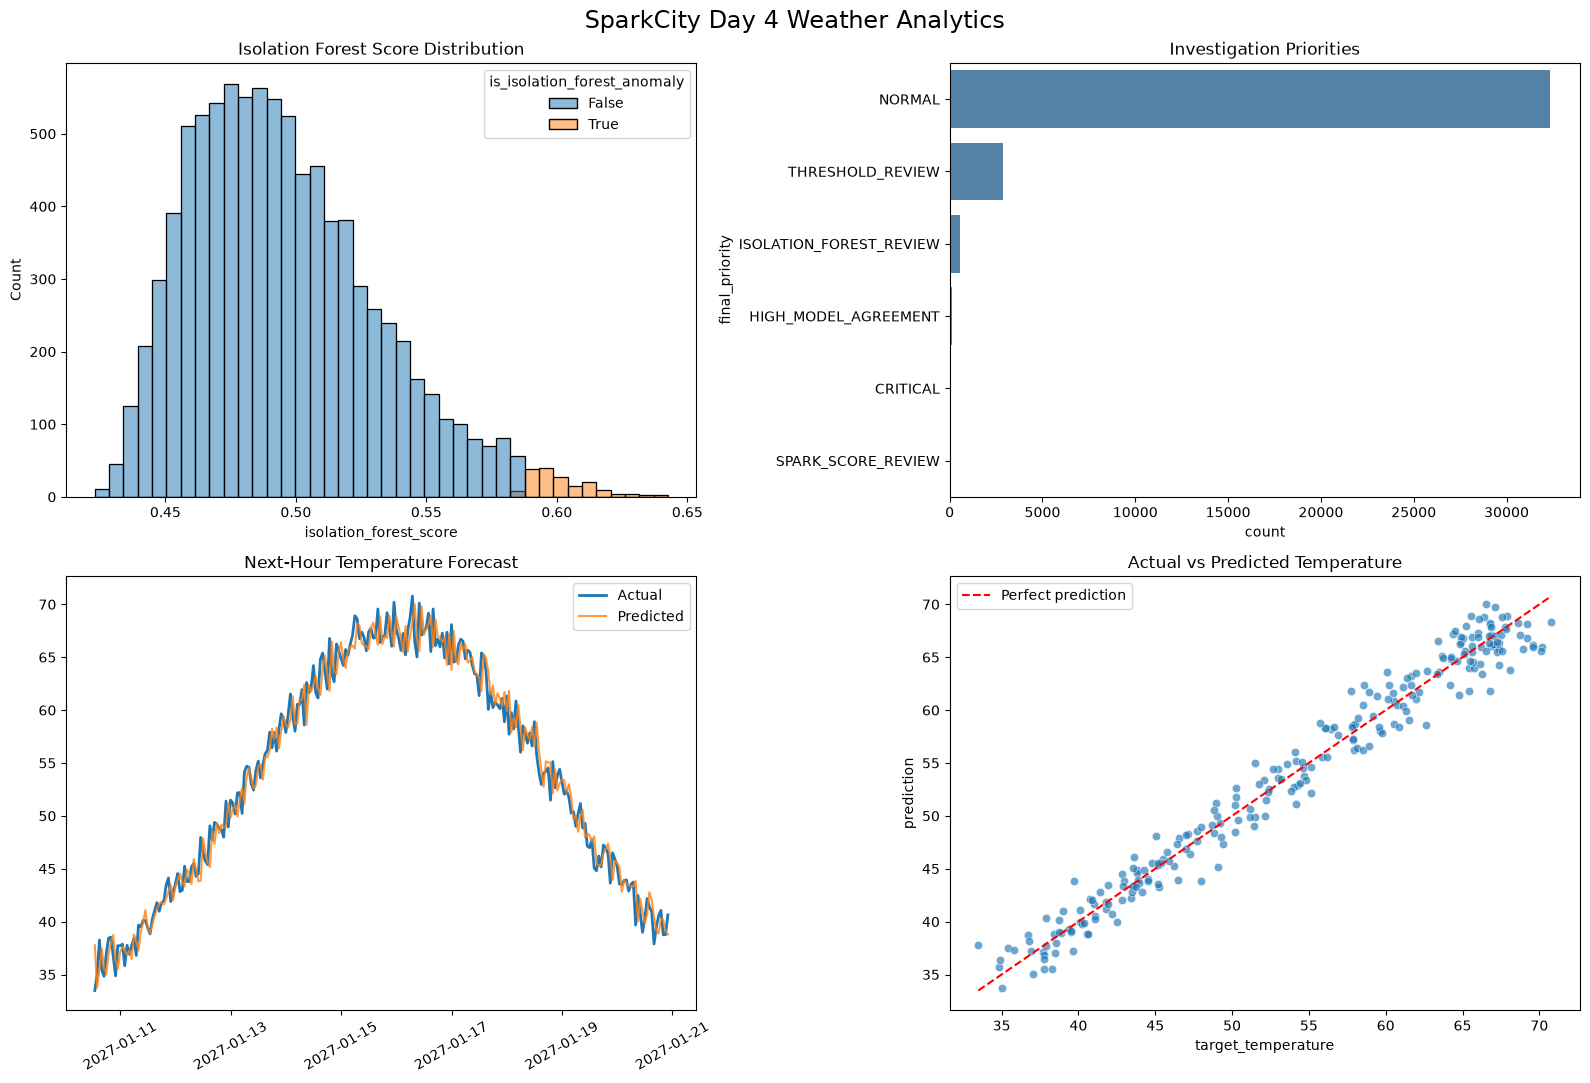

In [30]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11),
)

sns.histplot(
    data=anomaly_plot_df,
    x="isolation_forest_score",
    hue="is_isolation_forest_anomaly",
    bins=40,
    ax=axes[0, 0],
)

axes[0, 0].set_title("Isolation Forest Score Distribution")

sns.barplot(
    data=priority_plot_df,
    x="count",
    y="final_priority",
    ax=axes[0, 1],
    color="steelblue",
)

axes[0, 1].set_title("Investigation Priorities")

axes[1, 0].plot(
    forecast_plot_df["hour_timestamp"],
    forecast_plot_df["target_temperature"],
    label="Actual",
    linewidth=2,
)

axes[1, 0].plot(
    forecast_plot_df["hour_timestamp"],
    forecast_plot_df["prediction"],
    label="Predicted",
    alpha=0.8,
)

axes[1, 0].set_title("Next-Hour Temperature Forecast")
axes[1, 0].tick_params(axis="x", rotation=30)
axes[1, 0].legend()

sns.scatterplot(
    data=forecast_plot_df,
    x="target_temperature",
    y="prediction",
    alpha=0.65,
    ax=axes[1, 1],
)

minimum_value = min(
    forecast_plot_df["target_temperature"].min(),
    forecast_plot_df["prediction"].min(),
)

maximum_value = max(
    forecast_plot_df["target_temperature"].max(),
    forecast_plot_df["prediction"].max(),
)

axes[1, 1].plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect prediction",
)

axes[1, 1].set_title("Actual vs Predicted Temperature")
axes[1, 1].legend()

figure.suptitle(
    "SparkCity Day 4 Weather Analytics",
    fontsize=17,
)

plt.tight_layout()
plt.show()

## 6. Day 4 Findings and Limitations

- Threshold alerts are explainable and include investigation reasons and recommended actions.
- Spark-native multivariate scoring provides transparent combined z-score detection.
- Isolation Forest satisfies the tree-based multivariate anomaly requirement and captures nonlinear patterns.
- The MLlib forecasting pipeline uses a chronological split to prevent future-data leakage.
- Forecast performance is compared with a persistence baseline rather than reported without context.
- Caching is useful for repeated actions, but its benefit depends on dataset size and workload.
- The current Isolation Forest implementation collects five selected feature columns into local memory. This is appropriate for the 36,000-row training dataset but would require a distributed implementation for production-scale data.
- Alert thresholds are dataset-relative because measurement units remain undocumented. They are not official emergency-weather thresholds.

In [31]:
threshold_alert_count = final_investigation_df.filter(
    F.col("alert_count") > 0
).count()

review_queue_count = final_investigation_df.filter(
    F.col("final_priority") != "NORMAL"
).count()

comparison = anomaly_comparison_df.first().asDict()

In [32]:
print("DAY 4 WEATHER ANALYTICS SUMMARY")
print("=" * 55)
print(f"Source weather records: {weather_count:,}")
print(f"Threshold-alert records: {threshold_alert_count:,}")
print(f"Spark multivariate anomalies: {multivariate_anomaly_count:,}")
print(f"Isolation Forest anomalies: {isolation_anomaly_count:,}")
print(f"Anomalies identified by both models: {comparison['both_models']:,}")
print(f"Final investigation queue: {review_queue_count:,}")
print()
print(f"Forecast training rows: {forecast_result.training_rows:,}")
print(f"Forecast test rows: {forecast_result.test_rows:,}")
print(f"Forecast RMSE: {forecast_result.metrics['rmse']:.4f}")
print(f"Forecast MAE: {forecast_result.metrics['mae']:.4f}")
print(f"Forecast R²: {forecast_result.metrics['r2']:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print()
print(f"Uncached repeated workload: {uncached_seconds:.4f} seconds")
print(f"Cached repeated workload: {cached_seconds:.4f} seconds")
print(
    "Repeated-workload improvement:",
    f"{repeat_workload_improvement:.2f}%",
)

DAY 4 WEATHER ANALYTICS SUMMARY
Source weather records: 36,000
Threshold-alert records: 3,461
Spark multivariate anomalies: 131
Isolation Forest anomalies: 720
Anomalies identified by both models: 117
Final investigation queue: 3,660

Forecast training rows: 14,397
Forecast test rows: 3,600
Forecast RMSE: 1.6658
Forecast MAE: 1.3318
Forecast R²: 0.9783
Baseline RMSE: 1.7446
RMSE improvement: 4.52%

Uncached repeated workload: 0.1914 seconds
Cached repeated workload: 0.1419 seconds
Repeated-workload improvement: 25.89%


In [33]:
isolation_scored_df.unpersist()
forecast_result.predictions.unpersist()

spark.stop()

print("Spark resources released successfully.")

Spark resources released successfully.
